**Датасет:** https://www.kaggle.com/datasets/mragpavank/insurance1

**Задача аппроксимации:** Определение стоимости медицинской страховки на основе данных о клиенте.

Выходная переменная: `charges` (обучение ведётся на `log(charges)`, предсказание переводится обратно через `exp`).
Входные переменные: `age`, `smoker` (нормализованный) и `bmi`.


In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 Загрузка датасета и обработка данных

In [ ]:
google_drive_path = '/content/drive/MyDrive/ТУСУР 425-М/1 курс/2 семестр/Интеллектуальные вычислительные системы (ИВС)/Лаб. раб. 1'
dataset_path = f'{google_drive_path}/insurance.csv'

data = pd.read_csv(dataset_path)
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [ ]:
print(data.isnull().sum())
print(data.duplicated().sum())

if data.duplicated().sum() > 0:
  data = data.drop_duplicates()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


## 2 Преобразование нечисловых данных в числовые

In [ ]:
data_formalized = data.copy()

data_formalized['sex'] = data_formalized['sex'].map({'male': 1, 'female': 0})
data_formalized['smoker'] = data_formalized['smoker'].map({'yes': 1, 'no': 0})
data_formalized = pd.get_dummies(data_formalized, columns=['region'], drop_first=True, dtype=int)

data_formalized.head(10)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
5,31,0,25.740,0,0,3756.62160,0,1,0
6,46,0,33.440,1,0,8240.58960,0,1,0
7,37,0,27.740,3,0,7281.50560,1,0,0
8,37,1,29.830,2,0,6406.41070,0,0,0
9,60,0,25.840,0,0,28923.13692,1,0,0


## 3 Корреляционный анализ по методу Спирмена

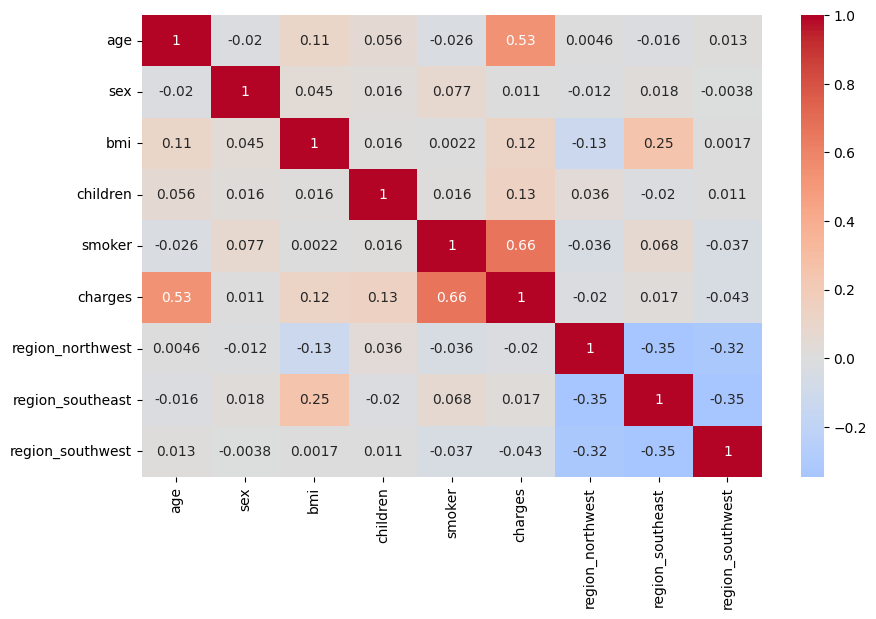

Корреляция признаков с выходной переменной charges: 
charges             1.000000
smoker              0.663611
age                 0.533523
children            0.132200
bmi                 0.119585
region_southeast    0.016609
sex                 0.010748
region_northwest   -0.019546
region_southwest   -0.043095
Name: charges, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

spearman_corr = data_formalized.corr(method='spearman')

plt.figure(figsize=(10, 6))
sns.heatmap(spearman_corr, cmap='coolwarm', annot=True, center=0)
plt.show()

corr_with_target = spearman_corr["charges"].sort_values(ascending=False)
print(f'Корреляция признаков с выходной переменной charges: \n{corr_with_target}')

## 4 Выбор 2-х наиболее значимых переменных

Выбранные признаки: ['age', 'smoker', 'bmi']


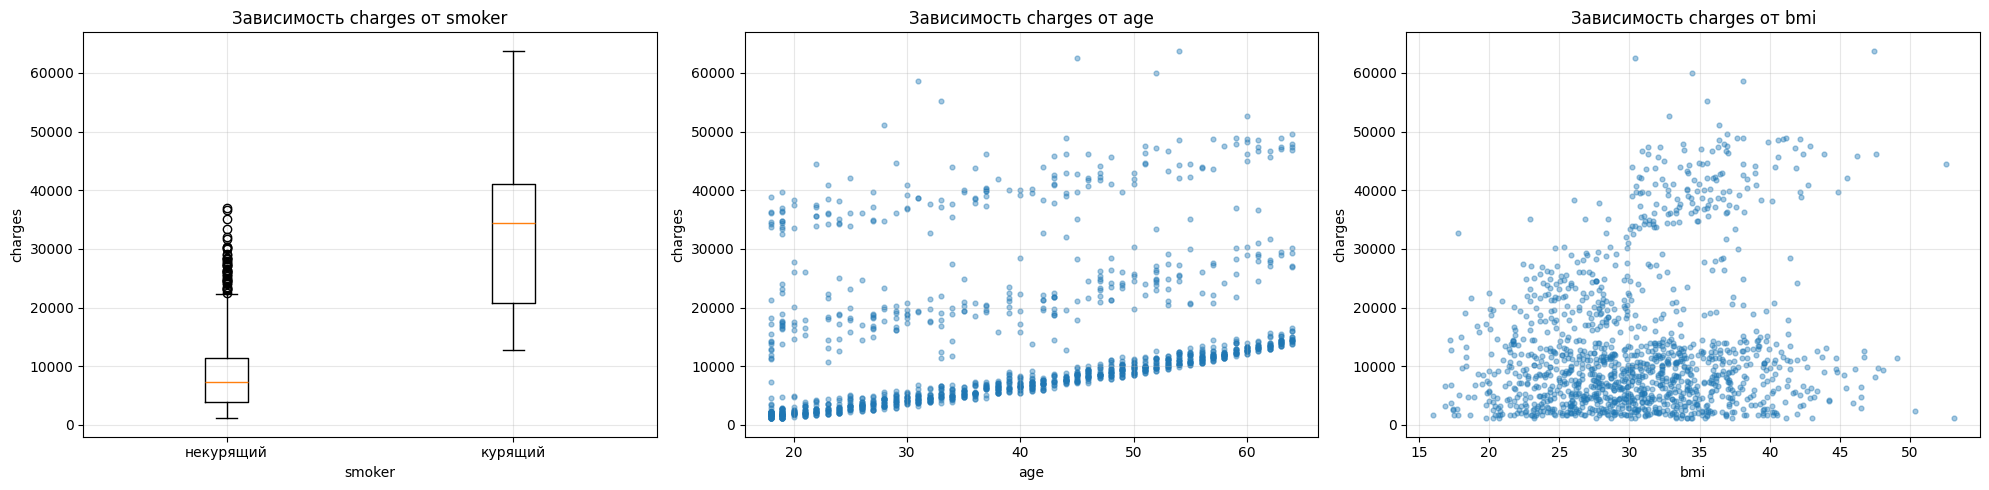

In [ ]:
selected_features = ['age', 'smoker', 'bmi']
print(f'Выбранные признаки: {selected_features}')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].boxplot([data[data['smoker'] == 'no']['charges'],
                 data[data['smoker'] == 'yes']['charges']],
                tick_labels=['некурящий', 'курящий'])
axes[0].set_xlabel('smoker')
axes[0].set_ylabel('charges')
axes[0].set_title('Зависимость charges от smoker')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(data['age'], data['charges'], alpha=0.4, s=12)
axes[1].set_xlabel('age')
axes[1].set_ylabel('charges')
axes[1].set_title('Зависимость charges от age')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(data['bmi'], data['charges'], alpha=0.4, s=12)
axes[2].set_xlabel('bmi')
axes[2].set_ylabel('charges')
axes[2].set_title('Зависимость charges от bmi')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5 Очистка датасета от выбросов

In [ ]:
data.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010



age:
-нижняя граница: -9.00
-верхняя граница: 87.00
-количество выбросов: 0 (0.00%)

bmi:
-нижняя граница: 13.67
-верхняя граница: 47.32
-количество выбросов: 9 (0.67%)

charges (анализ в log-масштабе, границы переведены обратно):
-нижняя граница: 721.90
-верхняя граница: 109521.63
-количество выбросов: 0 (0.00%)


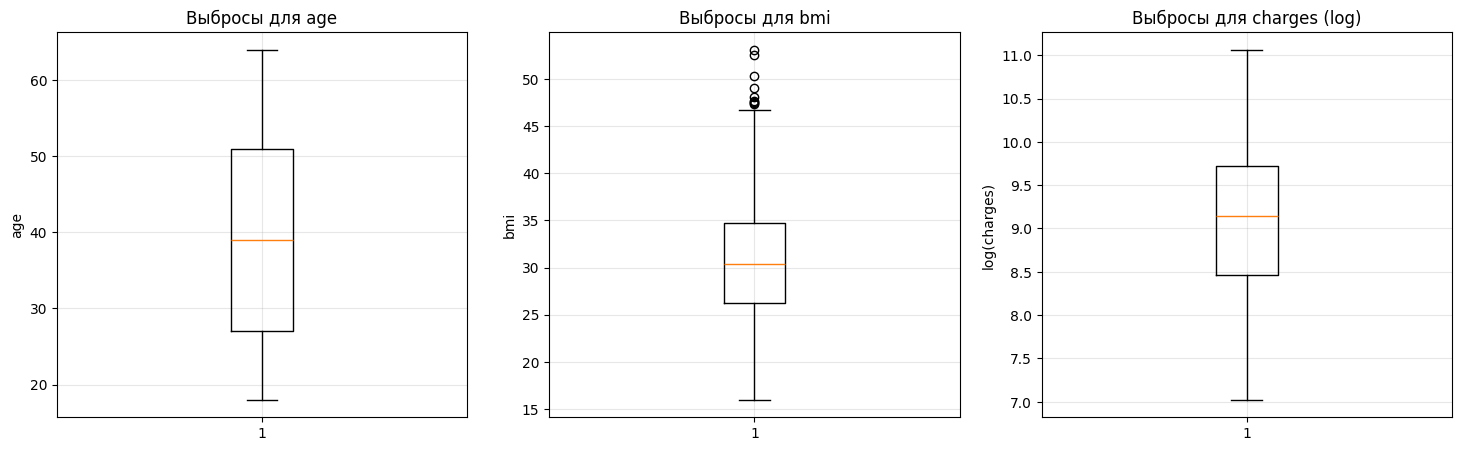

In [ ]:
def detect_outliers_iqr(data, column, log_scale=False):
    values = np.log(data[column]) if log_scale else data[column]
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    lower_log = Q1 - 1.5 * IQR
    upper_log = Q3 + 1.5 * IQR

    if log_scale:
        lower_bound = np.exp(lower_log)
        upper_bound = np.exp(upper_log)
    else:
        lower_bound = lower_log
        upper_bound = upper_log

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

log_scale_features = {'charges': True, 'age': False, 'bmi': False}
numerical_features = ['age', 'bmi', 'charges']

for feature in numerical_features:
    use_log = log_scale_features[feature]
    outliers, lower, upper = detect_outliers_iqr(data, feature, log_scale=use_log)
    log_note = ' (анализ в log-масштабе, границы переведены обратно)' if use_log else ''
    print(f'\n{feature}{log_note}:')
    print(f'-нижняя граница: {lower:.2f}')
    print(f'-верхняя граница: {upper:.2f}')
    print(f'-количество выбросов: {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, feature in enumerate(numerical_features):
    use_log = log_scale_features[feature]
    plot_data = np.log(data[feature]) if use_log else data[feature]
    axes[idx].boxplot(plot_data)
    title_suffix = ' (log)' if use_log else ''
    axes[idx].set_title(f'Выбросы для {feature}{title_suffix}')
    axes[idx].set_ylabel(f'log({feature})' if use_log else feature)
    axes[idx].grid(True, alpha=0.3)
plt.show()

Исходный размер датасета: 1337 строк
После удаления выбросов по age осталось: 1337 строк
После удаления выбросов по bmi осталось: 1328 строк
После удаления выбросов по charges осталось: 1328 строк

Всего удалено: 9 строк (0.67%)


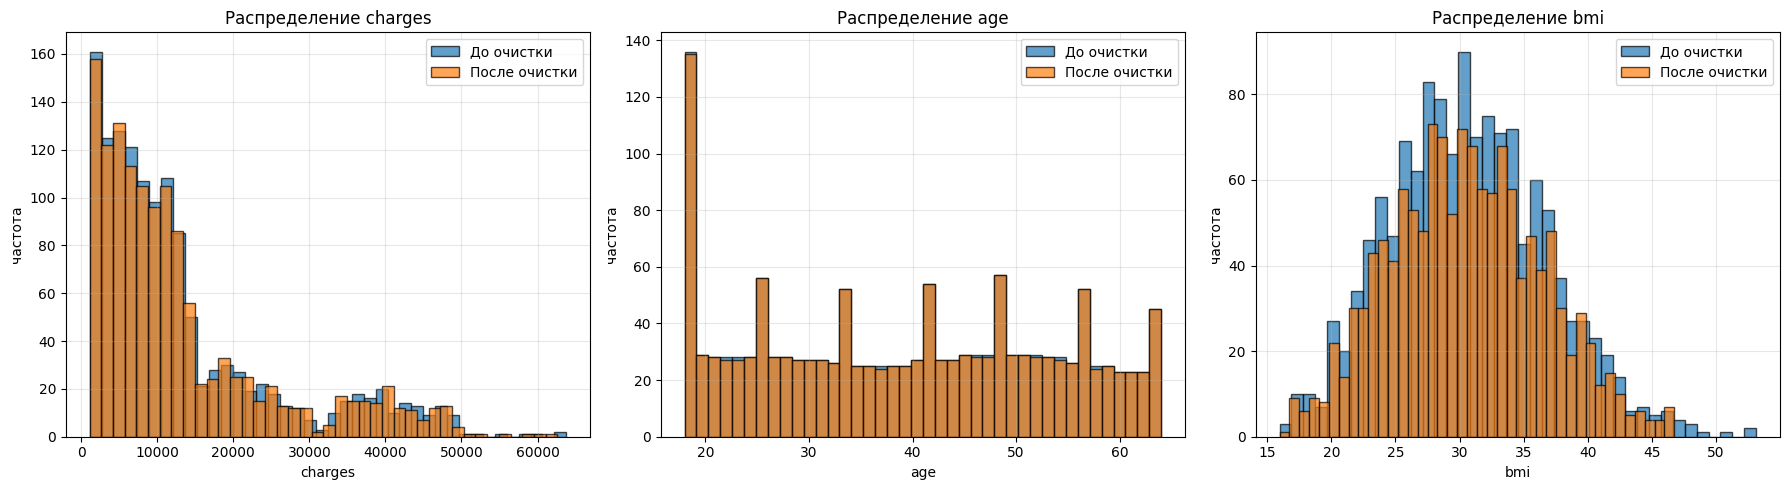

In [ ]:
print(f'Исходный размер датасета: {len(data)} строк')

data_clean = data.copy()

outliers_age, lower_age, upper_age = detect_outliers_iqr(data_clean, 'age')
data_clean = data_clean[
    (data_clean['age'] >= lower_age) & (data_clean['age'] <= upper_age)
]
print(f'После удаления выбросов по age осталось: {len(data_clean)} строк')

outliers_bmi, lower_bmi, upper_bmi = detect_outliers_iqr(data_clean, 'bmi')
data_clean = data_clean[
    (data_clean['bmi'] >= lower_bmi) & (data_clean['bmi'] <= upper_bmi)
]
print(f'После удаления выбросов по bmi осталось: {len(data_clean)} строк')

outliers_charges, lower_charges, upper_charges = detect_outliers_iqr(data_clean, 'charges', log_scale=True)
data_clean = data_clean[
    (data_clean['charges'] >= lower_charges) & (data_clean['charges'] <= upper_charges)
]
print(f'После удаления выбросов по charges осталось: {len(data_clean)} строк')
print(f'\nВсего удалено: {len(data) - len(data_clean)} строк '
      f'({(len(data)-len(data_clean))/len(data)*100:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['charges', 'age', 'bmi']):
    ax.hist(data[col], bins=40, alpha=0.7, label='До очистки', edgecolor='black')
    ax.hist(data_clean[col], bins=40, alpha=0.7, label='После очистки', edgecolor='black')
    ax.set_xlabel(col); ax.set_ylabel('частота')
    ax.set_title(f'Распределение {col}')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6 Разбиение датасета на обучающую и экспериментальную выборки

In [ ]:
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data_clean, test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {len(train_data)} строк ({len(train_data)/len(data_clean)*100:.1f}%)")
print(f"Размер тестовой выборки: {len(test_data)} строк ({len(test_data)/len(data_clean)*100:.1f}%)")

clean_path = f'{google_drive_path}/insurance_clean.csv'
train_path = f'{google_drive_path}/insurance_train.csv'
test_path = f'{google_drive_path}/insurance_test.csv'

data_clean.to_csv(clean_path, index=False)
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

Размер обучающей выборки: 929 строк (70.0%)
Размер тестовой выборки: 399 строк (30.0%)


## 6.5 Нормализация признака smoker

Условные средние charges по группам smoker:
  smoker=no: 8448.60
  smoker=yes: 31835.34

Пример нормализованных значений smoker_norm:
smoker  smoker_norm     charges
   yes          1.0 16884.92400
    no          0.0  1725.55230
    no          0.0  4449.46200
    no          0.0 21984.47061
    no          0.0  3866.85520
    no          0.0  3756.62160
    no          0.0  8240.58960
    no          0.0  7281.50560
    no          0.0  6406.41070
    no          0.0 28923.13692

Диапазон smoker_norm: [0.00, 1.00]
Диапазон bmi: [15.96, 46.75]

Обучающая: 929 строк | Тестовая: 399 строк


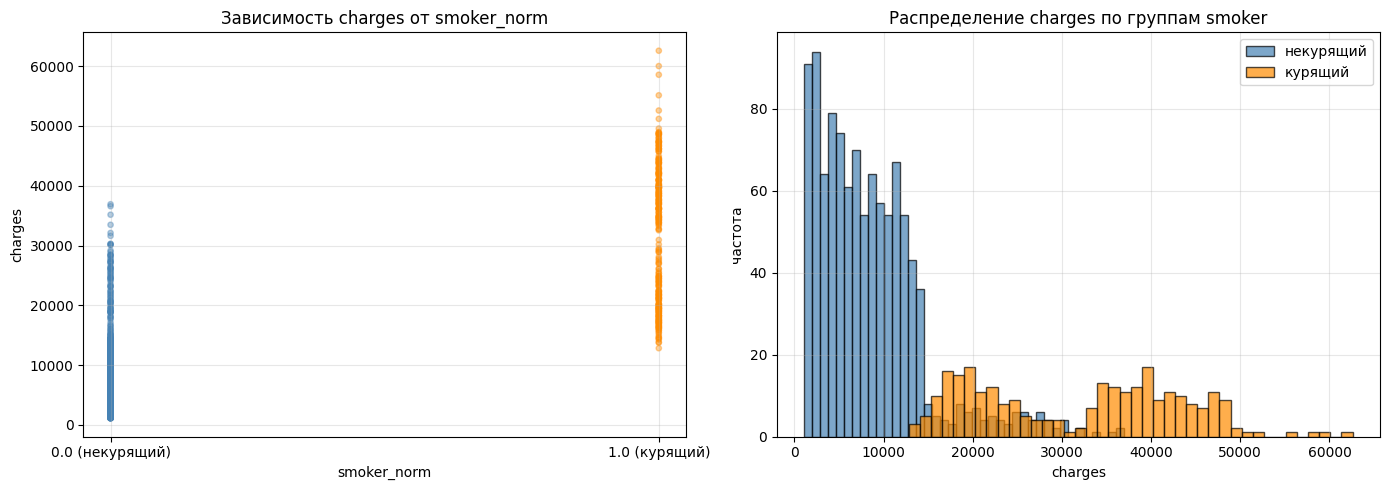

In [ ]:
cond_means = data_clean.groupby('smoker')['charges'].mean()
print('Условные средние charges по группам smoker:')
for grp, val in cond_means.items():
    print(f'  smoker={grp}: {val:.2f}')

mean_no  = cond_means['no']
mean_yes = cond_means['yes']
smoker_norm_map = {
    'no':  0.0,
    'yes': 1.0,
}

data_clean = data_clean.copy()
data_clean['smoker_norm'] = data_clean['smoker'].map(smoker_norm_map)

print(f'\nПример нормализованных значений smoker_norm:')
print(data_clean[['smoker', 'smoker_norm', 'charges']].head(10).to_string(index=False))

SMOKER_MIN = float(data_clean['smoker_norm'].min())
SMOKER_MAX = float(data_clean['smoker_norm'].max())
BMI_MIN = float(data_clean['bmi'].min())
BMI_MAX = float(data_clean['bmi'].max())
print(f'\nДиапазон smoker_norm: [{SMOKER_MIN:.2f}, {SMOKER_MAX:.2f}]')
print(f'Диапазон bmi: [{BMI_MIN:.2f}, {BMI_MAX:.2f}]')

from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(data_clean, test_size=0.3, random_state=42)
print(f'\nОбучающая: {len(train_data)} строк | Тестовая: {len(test_data)} строк')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = data_clean['smoker'].map({'no': 'steelblue', 'yes': 'darkorange'})
axes[0].scatter(data_clean['smoker_norm'], data_clean['charges'],
                c=colors, alpha=0.4, s=15)
axes[0].set_xlabel('smoker_norm'); axes[0].set_ylabel('charges')
axes[0].set_title('Зависимость charges от smoker_norm')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0.0 (некурящий)', '1.0 (курящий)'])
axes[0].grid(True, alpha=0.3)

axes[1].hist(data_clean[data_clean['smoker']=='no']['charges'],
             bins=40, alpha=0.7, label='некурящий', edgecolor='black', color='steelblue')
axes[1].hist(data_clean[data_clean['smoker']=='yes']['charges'],
             bins=40, alpha=0.7, label='курящий', edgecolor='black', color='darkorange')
axes[1].set_xlabel('charges'); axes[1].set_ylabel('частота')
axes[1].set_title('Распределение charges по группам smoker')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7 Разбиение на термы



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

AGE_MIN = float(data_clean['age'].min())
AGE_MAX = float(data_clean['age'].max())

style  = {'description_width': '240px'}
layout = widgets.Layout(width='400px')

w_age = widgets.BoundedIntText(value=5, min=2, max=20,
    description='Количество термов для age:', style=style, layout=layout)
w_smoker = widgets.BoundedIntText(value=2, min=2, max=10,
    description='Количество термов для smoker:', style=style, layout=layout)
w_bmi = widgets.BoundedIntText(value=5, min=2, max=20,
    description='Количество термов для bmi:', style=style, layout=layout)
btn = widgets.Button(description='Применить', button_style='primary',
                     layout=widgets.Layout(width='160px', margin='10px 0 0 0'))
out = widgets.Output()

AGE_TERM_NUMBER = None
SMOKER_TERM_NUMBER = None
BMI_TERM_NUMBER = None
age_term_names = None
smoker_term_names = None
bmi_term_names = None
x = None
x_smoker = None
x_bmi = None

def generate_term_names(n):
    return [f'терм {i+1}' for i in range(n)]

def on_apply(b):
    global AGE_TERM_NUMBER, SMOKER_TERM_NUMBER, BMI_TERM_NUMBER
    global age_term_names, smoker_term_names, bmi_term_names
    global x, x_smoker, x_bmi

    AGE_TERM_NUMBER = w_age.value
    SMOKER_TERM_NUMBER = w_smoker.value
    BMI_TERM_NUMBER = w_bmi.value
    age_term_names = generate_term_names(AGE_TERM_NUMBER)
    smoker_term_names = generate_term_names(SMOKER_TERM_NUMBER)
    bmi_term_names = generate_term_names(BMI_TERM_NUMBER)
    x = np.linspace(AGE_MIN, AGE_MAX, 500)
    x_smoker = np.linspace(SMOKER_MIN, SMOKER_MAX, 500)
    x_bmi = np.linspace(BMI_MIN, BMI_MAX, 500)

    with out:
        clear_output()
        print(f'age: {AGE_TERM_NUMBER} термов → {age_term_names}')
        print(f'smoker: {SMOKER_TERM_NUMBER} термов → {smoker_term_names}')
        print(f'bmi: {BMI_TERM_NUMBER} термов → {bmi_term_names}')
        print(f'Диапазон age: [{AGE_MIN:.1f}, {AGE_MAX:.1f}]')
        print(f'Диапазон smoker: [{SMOKER_MIN:.2f}, {SMOKER_MAX:.2f}]')
        print(f'Диапазон bmi: [{BMI_MIN:.2f}, {BMI_MAX:.2f}]')

btn.on_click(on_apply)
on_apply(None)

display(
    widgets.VBox([
        widgets.HTML('<b>Настройка разбиения на термы</b>'),
        w_age, w_smoker, w_bmi, btn, out
    ])
)

### 7.1 Термы для треугольной функции принадлежности

In [ ]:
def generate_triangular_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else (max_value - min_value)
    terms = []
    for i in range(n_terms):
        if i == 0:
            a, b, c = min_value, centers[i], centers[i] + step
        elif i == n_terms - 1:
            a, b, c = centers[i] - step, centers[i], max_value
        else:
            a, b, c = centers[i] - step, centers[i], centers[i] + step
        terms.append((a, b, c))
    return terms

age_triangular = generate_triangular_terms(AGE_MIN, AGE_MAX, AGE_TERM_NUMBER)
smoker_triangular = generate_triangular_terms(SMOKER_MIN, SMOKER_MAX, SMOKER_TERM_NUMBER)
bmi_triangular = generate_triangular_terms(BMI_MIN, BMI_MAX, BMI_TERM_NUMBER)

for label, terms, names in [
    (f'age ({AGE_TERM_NUMBER} шт.)', age_triangular, age_term_names),
    (f'smoker ({SMOKER_TERM_NUMBER} шт.)', smoker_triangular, smoker_term_names),
    (f'bmi ({BMI_TERM_NUMBER} шт.)', bmi_triangular, bmi_term_names),
]:
    print(f'Треугольные термы для {label}:')
    for name, (a, b, c) in zip(names, terms):
        print(f'{name}: a={a:.3f}, b={b:.3f}, c={c:.3f}')
    print()

Треугольные термы для age (5 шт.):
терм 1: a=18.000, b=18.000, c=29.500
терм 2: a=18.000, b=29.500, c=41.000
терм 3: a=29.500, b=41.000, c=52.500
терм 4: a=41.000, b=52.500, c=64.000
терм 5: a=52.500, b=64.000, c=64.000

Треугольные термы для smoker (2 шт.):
терм 1: a=0.000, b=0.000, c=1.000
терм 2: a=0.000, b=1.000, c=1.000

Треугольные термы для bmi (5 шт.):
терм 1: a=15.960, b=15.960, c=23.657
терм 2: a=15.960, b=23.657, c=31.355
терм 3: a=23.658, b=31.355, c=39.052
терм 4: a=31.355, b=39.053, c=46.750
терм 5: a=39.053, b=46.750, c=46.750



### 7.2 Термы для трапецеидальной функции принадлежности

In [ ]:
def generate_trapezoidal_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else (max_value - min_value)
    terms = []
    for i in range(n_terms):
        if i == 0:
            a, b, c, d = min_value, min_value, centers[i]+step/2, centers[i]+step
        elif i == n_terms - 1:
            a, b, c, d = centers[i]-step, centers[i]-step/2, max_value, max_value
        else:
            a, b, c, d = centers[i]-step, centers[i]-step/2, centers[i]+step/2, centers[i]+step
        terms.append((a, b, c, d))
    return terms

age_trapezoidal = generate_trapezoidal_terms(AGE_MIN, AGE_MAX, AGE_TERM_NUMBER)
smoker_trapezoidal = generate_trapezoidal_terms(SMOKER_MIN, SMOKER_MAX, SMOKER_TERM_NUMBER)
bmi_trapezoidal = generate_trapezoidal_terms(BMI_MIN, BMI_MAX, BMI_TERM_NUMBER)

for label, terms, names in [
    (f'age ({AGE_TERM_NUMBER} шт.)', age_trapezoidal, age_term_names),
    (f'smoker ({SMOKER_TERM_NUMBER} шт.)', smoker_trapezoidal, smoker_term_names),
    (f'bmi ({BMI_TERM_NUMBER} шт.)', bmi_trapezoidal, bmi_term_names),
]:
    print(f'Трапецеидальные термы для {label}:')
    for name, (a, b, c, d) in zip(names, terms):
        print(f'{name}: a={a:.3f}, b={b:.3f}, c={c:.3f}, d={d:.3f}')
    print()

Трапецеидальные термы для age (5 шт.):
терм 1: a=18.000, b=18.000, c=23.750, d=29.500
терм 2: a=18.000, b=23.750, c=35.250, d=41.000
терм 3: a=29.500, b=35.250, c=46.750, d=52.500
терм 4: a=41.000, b=46.750, c=58.250, d=64.000
терм 5: a=52.500, b=58.250, c=64.000, d=64.000

Трапецеидальные термы для smoker (2 шт.):
терм 1: a=0.000, b=0.000, c=0.500, d=1.000
терм 2: a=0.000, b=0.500, c=1.000, d=1.000

Трапецеидальные термы для bmi (5 шт.):
терм 1: a=15.960, b=15.960, c=19.809, d=23.657
терм 2: a=15.960, b=19.809, c=27.506, d=31.355
терм 3: a=23.658, b=27.506, c=35.204, d=39.052
терм 4: a=31.355, b=35.204, c=42.901, d=46.750
терм 5: a=39.053, b=42.901, c=46.750, d=46.750



### 7.3 Термы для параболической функции принадлежности

In [ ]:
def generate_parabolic_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else (max_value - min_value)
    return [(c, step) for c in centers]

age_parabolic = generate_parabolic_terms(AGE_MIN, AGE_MAX, AGE_TERM_NUMBER)
smoker_parabolic = generate_parabolic_terms(SMOKER_MIN, SMOKER_MAX, SMOKER_TERM_NUMBER)
bmi_parabolic = generate_parabolic_terms(BMI_MIN, BMI_MAX, BMI_TERM_NUMBER)

for label, terms, names in [
    (f'age ({AGE_TERM_NUMBER} шт.)', age_parabolic, age_term_names),
    (f'smoker ({SMOKER_TERM_NUMBER} шт.)', smoker_parabolic, smoker_term_names),
    (f'bmi ({BMI_TERM_NUMBER} шт.)', bmi_parabolic, bmi_term_names),
]:
    print(f'Параболические термы для {label}:')
    for name, (c, w) in zip(names, terms):
        print(f'{name}: центр={c:.3f}, ширина={w:.3f}')
    print()

Параболические термы для age (5 шт.):
терм 1: центр=18.000, ширина=11.500
терм 2: центр=29.500, ширина=11.500
терм 3: центр=41.000, ширина=11.500
терм 4: центр=52.500, ширина=11.500
терм 5: центр=64.000, ширина=11.500

Параболические термы для smoker (2 шт.):
терм 1: центр=0.000, ширина=1.000
терм 2: центр=1.000, ширина=1.000

Параболические термы для bmi (5 шт.):
терм 1: центр=15.960, ширина=7.697
терм 2: центр=23.657, ширина=7.697
терм 3: центр=31.355, ширина=7.697
терм 4: центр=39.053, ширина=7.697
терм 5: центр=46.750, ширина=7.697



### 7.4 Термы для Гауссовой функции принадлежности

In [ ]:
def generate_gaussian_terms(min_value, max_value, n_terms):
    centers = np.linspace(min_value, max_value, n_terms)
    step = centers[1] - centers[0] if n_terms > 1 else (max_value - min_value)
    return [(c, step) for c in centers]

age_gaussian = generate_gaussian_terms(AGE_MIN, AGE_MAX, AGE_TERM_NUMBER)
smoker_gaussian = generate_gaussian_terms(SMOKER_MIN, SMOKER_MAX, SMOKER_TERM_NUMBER)
bmi_gaussian = generate_gaussian_terms(BMI_MIN, BMI_MAX, BMI_TERM_NUMBER)

for label, terms, names in [
    (f'age ({AGE_TERM_NUMBER} шт.)', age_gaussian, age_term_names),
    (f'smoker ({SMOKER_TERM_NUMBER} шт.)', smoker_gaussian, smoker_term_names),
    (f'bmi ({BMI_TERM_NUMBER} шт.)', bmi_gaussian, bmi_term_names),
]:
    print(f'Гауссовы термы для {label}:')
    for name, (c, s) in zip(names, terms):
        print(f'{name}: центр={c:.3f}, sigma={s:.3f}')
    print()

Гауссовы термы для age (5 шт.):
терм 1: центр=18.000, sigma=11.500
терм 2: центр=29.500, sigma=11.500
терм 3: центр=41.000, sigma=11.500
терм 4: центр=52.500, sigma=11.500
терм 5: центр=64.000, sigma=11.500

Гауссовы термы для smoker (2 шт.):
терм 1: центр=0.000, sigma=1.000
терм 2: центр=1.000, sigma=1.000

Гауссовы термы для bmi (5 шт.):
терм 1: центр=15.960, sigma=7.697
терм 2: центр=23.657, sigma=7.697
терм 3: центр=31.355, sigma=7.697
терм 4: центр=39.053, sigma=7.697
терм 5: центр=46.750, sigma=7.697



## 8 Реализация функций принадлежности

### 8.1 Треугольная функция принадлежности

In [ ]:
def triangular(x, a, b, c):
    # Обработка граничных случаев для предотвращения деления на ноль
    if a == b and b == c:
        return np.where(x == a, 1.0, 0.0)
    elif a == b:
        return np.maximum(0, np.minimum(1, (c - x) / (c - a)))
    elif b == c:
        return np.maximum(0, np.minimum(1, (x - a) / (b - a)))
    else:
        return np.maximum(
            np.minimum((x - a) / (b - a), (c - x) / (c - b)),
            0
        )

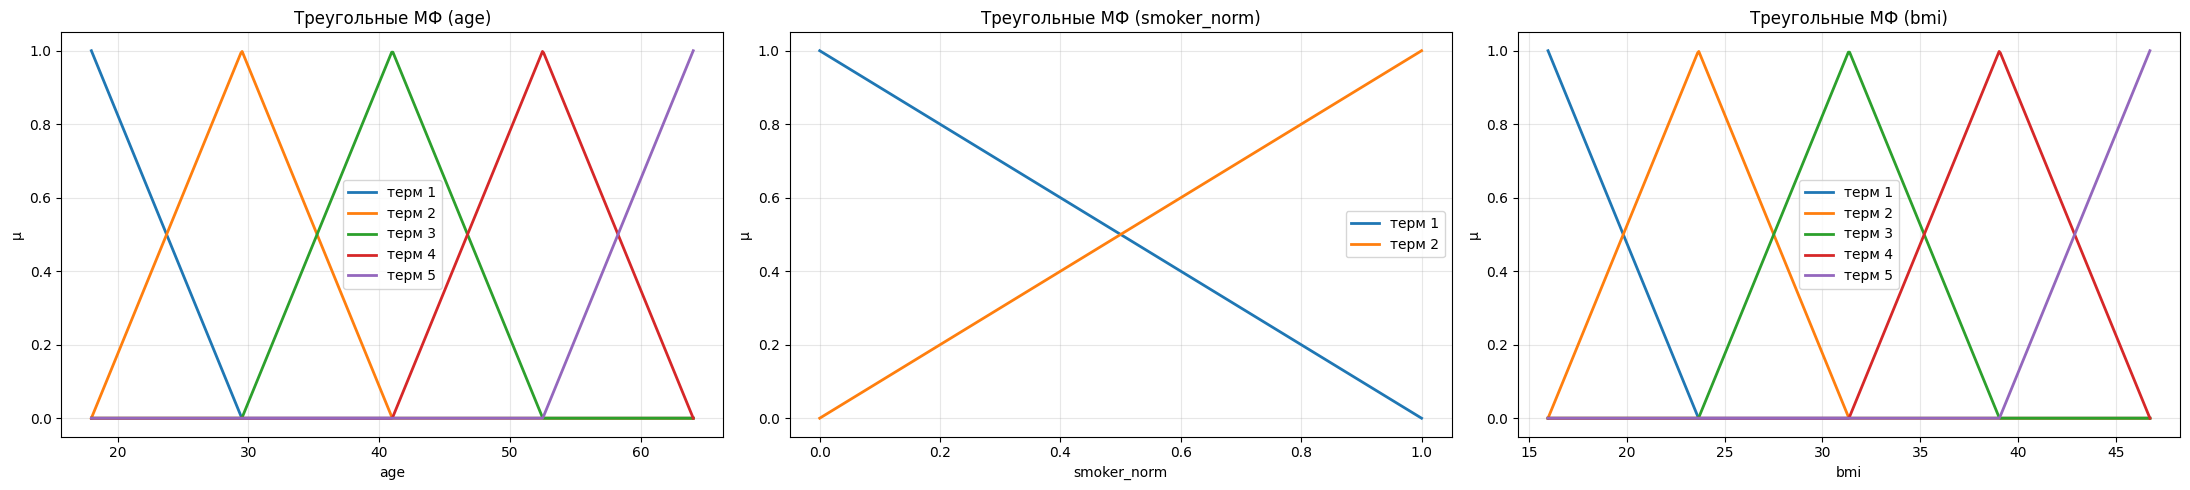

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for i, (a, b, c) in enumerate(age_triangular):
    axes[0].plot(x, triangular(x, a, b, c), linewidth=2, label=age_term_names[i])
axes[0].set_title('Треугольные МФ (age)'); axes[0].set_xlabel('age')
axes[0].set_ylabel('μ'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
for i, (a, b, c) in enumerate(smoker_triangular):
    axes[1].plot(x_smoker, triangular(x_smoker, a, b, c), linewidth=2, label=smoker_term_names[i])
axes[1].set_title('Треугольные МФ (smoker_norm)'); axes[1].set_xlabel('smoker_norm')
axes[1].set_ylabel('μ'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
for i, (a, b, c) in enumerate(bmi_triangular):
    axes[2].plot(x_bmi, triangular(x_bmi, a, b, c), linewidth=2, label=bmi_term_names[i])
axes[2].set_title('Треугольные МФ (bmi)'); axes[2].set_xlabel('bmi')
axes[2].set_ylabel('μ'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 8.2 Трапециевидная функция принадлежности

In [ ]:
def trapezoidal(x, a, b, c, d):
    # Обработка граничных случаев для предотвращения деления на ноль
    if a == b and c == d:
        return np.where((x >= a) & (x <= d), 1.0, 0.0)
    elif a == b:
        left_part = np.where(x >= a, 1.0, 0.0)
        right_part = np.where(x <= d, (d - x) / (d - c), 0.0)
        return np.minimum(left_part, np.maximum(right_part, 0))
    elif c == d:
        left_part = np.where(x >= a, (x - a) / (b - a), 0.0)
        right_part = np.where(x <= d, 1.0, 0.0)
        return np.minimum(np.maximum(left_part, 0), right_part)
    else:
        return np.maximum(
            np.minimum(
                np.minimum((x - a) / (b - a), 1),
                (d - x) / (d - c)
            ),
            0
        )

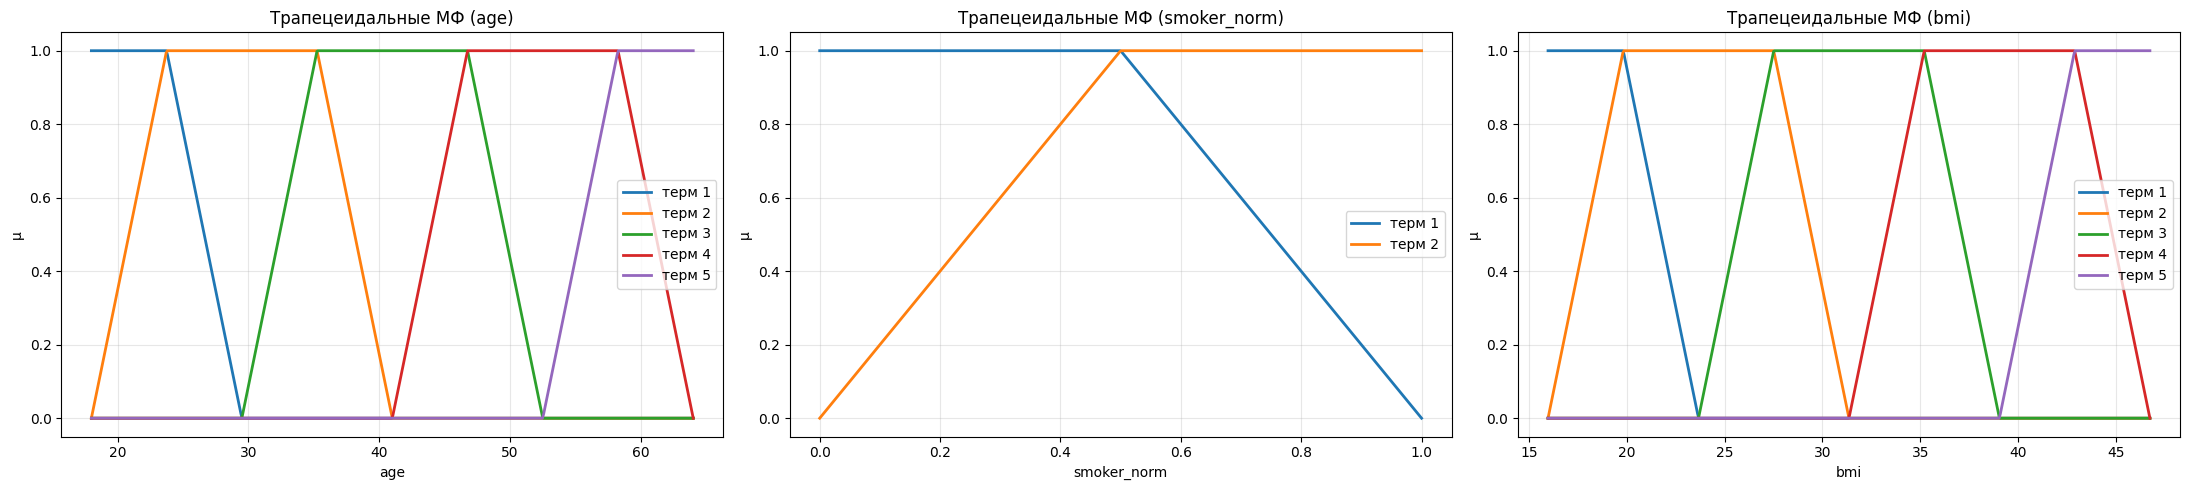

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for i, (a, b, c, d) in enumerate(age_trapezoidal):
    axes[0].plot(x, trapezoidal(x, a, b, c, d), linewidth=2, label=age_term_names[i])
axes[0].set_title('Трапецеидальные МФ (age)'); axes[0].set_xlabel('age')
axes[0].set_ylabel('μ'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
for i, (a, b, c, d) in enumerate(smoker_trapezoidal):
    axes[1].plot(x_smoker, trapezoidal(x_smoker, a, b, c, d), linewidth=2, label=smoker_term_names[i])
axes[1].set_title('Трапецеидальные МФ (smoker_norm)'); axes[1].set_xlabel('smoker_norm')
axes[1].set_ylabel('μ'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
for i, (a, b, c, d) in enumerate(bmi_trapezoidal):
    axes[2].plot(x_bmi, trapezoidal(x_bmi, a, b, c, d), linewidth=2, label=bmi_term_names[i])
axes[2].set_title('Трапецеидальные МФ (bmi)'); axes[2].set_xlabel('bmi')
axes[2].set_ylabel('μ'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 8.3 Параболическая функция принадлежности

In [ ]:
def parabolic(x, center, width):
    # Вырожденный случай
    if width == 0:
        return np.where(x == center, 1.0, 0.0)

    mu = 1 - ((x - center) / width) ** 2
    mu = np.where(np.abs(x - center) <= width, mu, 0)

    return np.maximum(mu, 0)

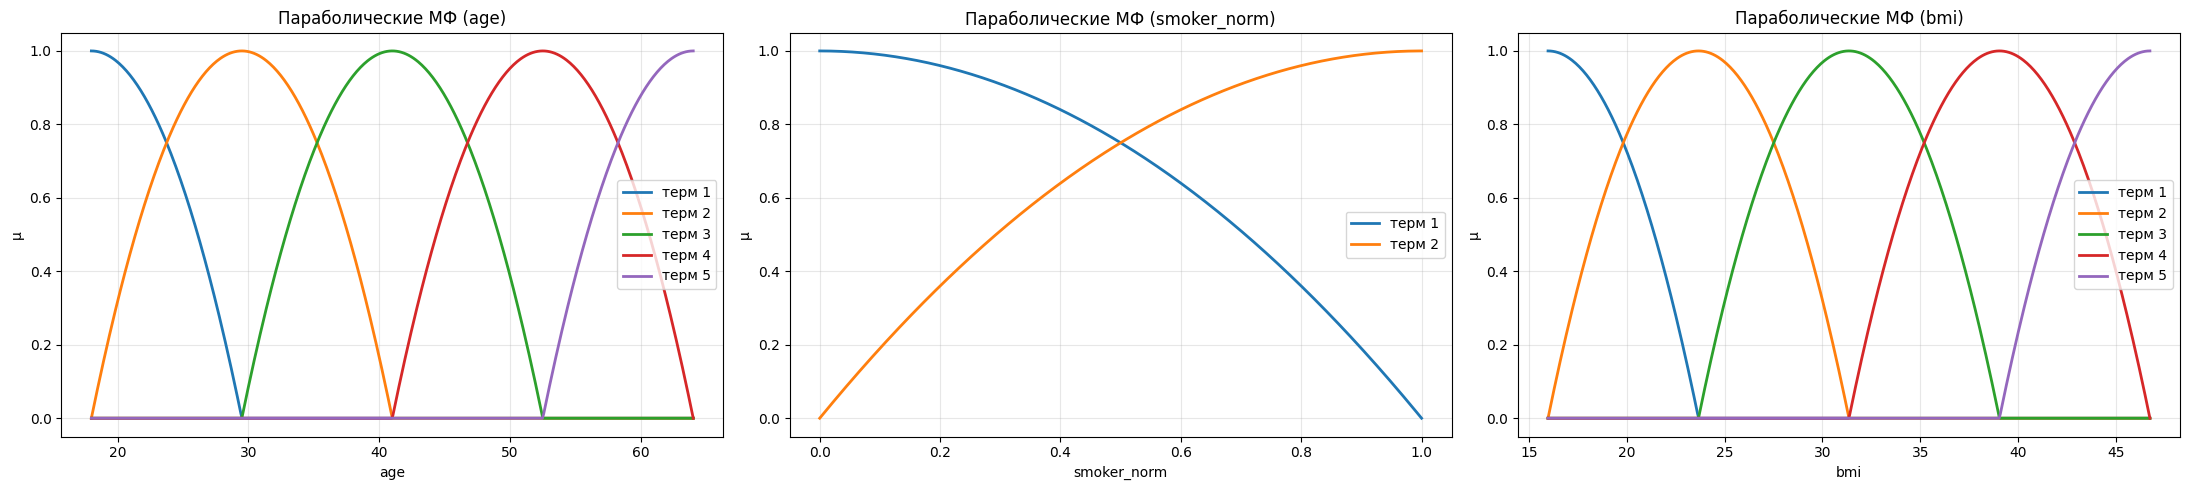

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for i, (c, w) in enumerate(age_parabolic):
    axes[0].plot(x, parabolic(x, c, w), linewidth=2, label=age_term_names[i])
axes[0].set_title('Параболические МФ (age)'); axes[0].set_xlabel('age')
axes[0].set_ylabel('μ'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
for i, (c, w) in enumerate(smoker_parabolic):
    axes[1].plot(x_smoker, parabolic(x_smoker, c, w), linewidth=2, label=smoker_term_names[i])
axes[1].set_title('Параболические МФ (smoker_norm)'); axes[1].set_xlabel('smoker_norm')
axes[1].set_ylabel('μ'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
for i, (c, w) in enumerate(bmi_parabolic):
    axes[2].plot(x_bmi, parabolic(x_bmi, c, w), linewidth=2, label=bmi_term_names[i])
axes[2].set_title('Параболические МФ (bmi)'); axes[2].set_xlabel('bmi')
axes[2].set_ylabel('μ'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### 8.4 Гауссова функция принадлежности

In [ ]:
def gaussian(x, mean, sigma):
    # Вырожденный случай
    if sigma == 0:
        return np.where(x == mean, 1.0, 0.0)

    return np.exp(-((x - mean) / sigma) ** 2)

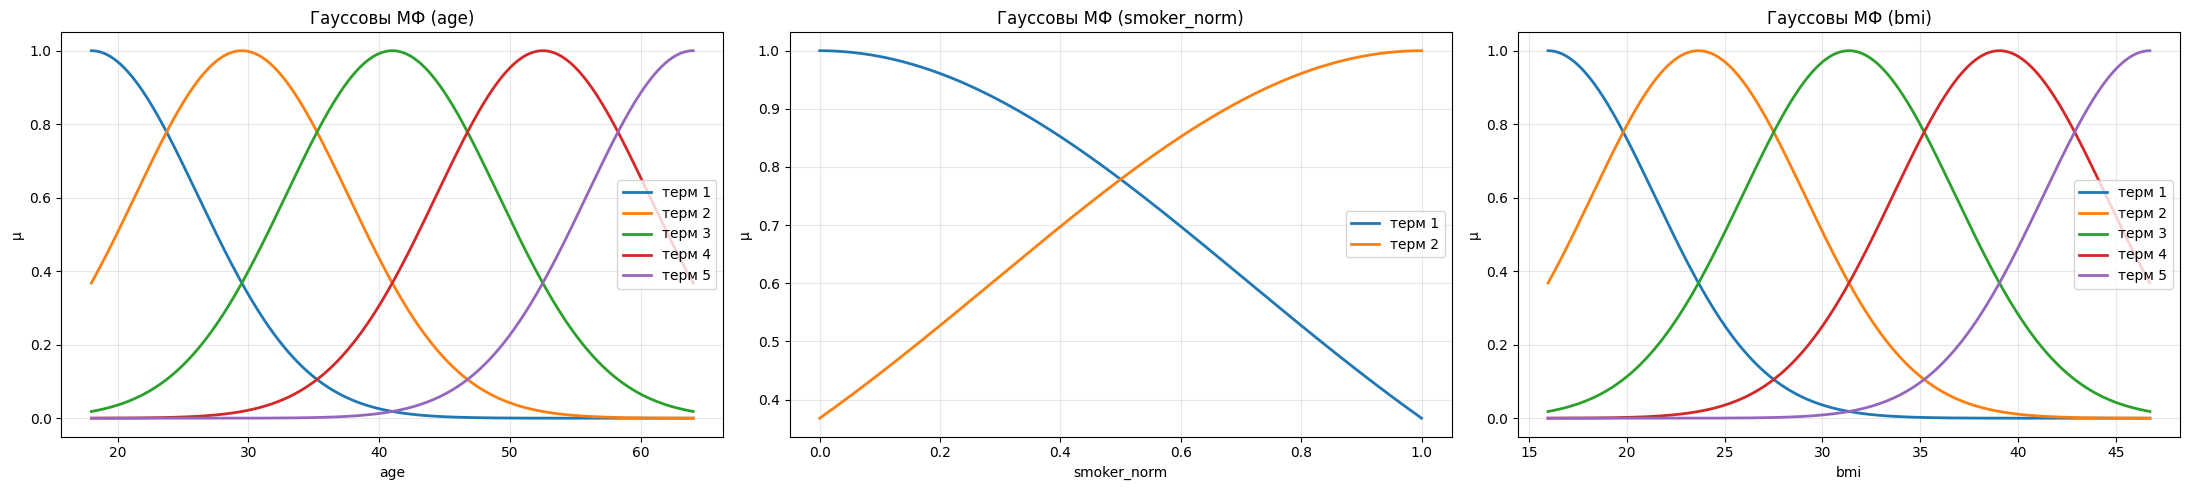

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))
for i, (c, s) in enumerate(age_gaussian):
    axes[0].plot(x, gaussian(x, c, s), linewidth=2, label=age_term_names[i])
axes[0].set_title('Гауссовы МФ (age)'); axes[0].set_xlabel('age')
axes[0].set_ylabel('μ'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
for i, (c, s) in enumerate(smoker_gaussian):
    axes[1].plot(x_smoker, gaussian(x_smoker, c, s), linewidth=2, label=smoker_term_names[i])
axes[1].set_title('Гауссовы МФ (smoker_norm)'); axes[1].set_xlabel('smoker_norm')
axes[1].set_ylabel('μ'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
for i, (c, s) in enumerate(bmi_gaussian):
    axes[2].plot(x_bmi, gaussian(x_bmi, c, s), linewidth=2, label=bmi_term_names[i])
axes[2].set_title('Гауссовы МФ (bmi)'); axes[2].set_xlabel('bmi')
axes[2].set_ylabel('μ'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9 Нечёткая система Такаги – Сугено

### 9.1 Выбор типа функции принадлежности

In [ ]:
mf_selector = widgets.ToggleButtons(
    options=['triangular', 'trapezoidal', 'parabolic', 'gaussian'],
    description='Функция принадлежности:',
    tooltips=['Треугольная', 'Трапецеидальная', 'Параболическая', 'Гауссова'],
    style={'description_width': '220px', 'button_width': '130px'},
    value='gaussian'
)
display(mf_selector)

ToggleButtons(description='Функция принадлежности:', index=3, options=('triangular', 'trapezoidal', 'parabolic…

### 9.2 Генерация термов по выбранному типу функции принадлежности

In [ ]:
def get_terms(min_val, max_val, n_terms, mf_type):
    if mf_type == 'triangular': return generate_triangular_terms(min_val, max_val, n_terms)
    elif mf_type == 'trapezoidal': return generate_trapezoidal_terms(min_val, max_val, n_terms)
    elif mf_type == 'parabolic': return generate_parabolic_terms(min_val, max_val, n_terms)
    elif mf_type == 'gaussian': return generate_gaussian_terms(min_val, max_val, n_terms)
    else: raise ValueError(f'Неизвестный тип: {mf_type}')

MATH_FUNC_TYPE = mf_selector.value

age_terms = get_terms(AGE_MIN, AGE_MAX, AGE_TERM_NUMBER, MATH_FUNC_TYPE)
smoker_terms = get_terms(SMOKER_MIN, SMOKER_MAX, SMOKER_TERM_NUMBER, MATH_FUNC_TYPE)
bmi_terms = get_terms(BMI_MIN, BMI_MAX, BMI_TERM_NUMBER, MATH_FUNC_TYPE)

print(f'Тип функции принадлежности: {MATH_FUNC_TYPE}')
for label, terms, names in [
    (f'age ({AGE_TERM_NUMBER} шт.)', age_terms, age_term_names),
    (f'smoker ({SMOKER_TERM_NUMBER} шт.)', smoker_terms, smoker_term_names),
    (f'bmi ({BMI_TERM_NUMBER} шт.)', bmi_terms, bmi_term_names),
]:
    print(f'\nТермы для {label}:')
    for name, params in zip(names, terms):
        print(f'{name}: {tuple(round(float(p), 4) for p in params)}')

print(f'\nВсего правил: {AGE_TERM_NUMBER} × {SMOKER_TERM_NUMBER} × {BMI_TERM_NUMBER} = '
      f'{AGE_TERM_NUMBER * SMOKER_TERM_NUMBER * BMI_TERM_NUMBER}')


Тип функции принадлежности: gaussian

Термы для age (5 шт.):
терм 1: (18.0, 11.5)
терм 2: (29.5, 11.5)
терм 3: (41.0, 11.5)
терм 4: (52.5, 11.5)
терм 5: (64.0, 11.5)

Термы для smoker (2 шт.):
терм 1: (0.0, 1.0)
терм 2: (1.0, 1.0)

Термы для bmi (5 шт.):
терм 1: (15.96, 7.6975)
терм 2: (23.6575, 7.6975)
терм 3: (31.355, 7.6975)
терм 4: (39.0525, 7.6975)
терм 5: (46.75, 7.6975)

Всего правил: 5 × 2 × 5 = 50


### 9.3 Функция вычисления степени принадлежности

In [ ]:
def membership_degree(x_val, term_params, math_func_type):
    x_arr = np.array([x_val])
    if math_func_type == 'triangular':
        a, b, c = term_params
        val = triangular(x_arr, a, b, c)
    elif math_func_type == 'trapezoidal':
        a, b, c, d = term_params
        val = trapezoidal(x_arr, a, b, c, d)
    elif math_func_type == 'parabolic':
        center, width = term_params
        val = parabolic(x_arr, center, width)
    elif math_func_type == 'gaussian':
        center, sigma = term_params
        val = gaussian(x_arr, center, sigma)
    else:
        raise ValueError(f'Неизвестный тип: {math_func_type}')
    return float(val[0])

### 9.4 Функция вычисления весов правил

In [ ]:
def compute_rule_weights(age_val, smoker_val, bmi_val,
                          age_terms, smoker_terms, bmi_terms, mf_type):

    mu_age = np.array([membership_degree(age_val, t, mf_type) for t in age_terms])
    mu_smoker = np.array([membership_degree(smoker_val, t, mf_type) for t in smoker_terms])
    mu_bmi = np.array([membership_degree(bmi_val, t, mf_type) for t in bmi_terms])

    weights = (mu_age[:, None, None] * mu_smoker[None, :, None] * mu_bmi[None, None, :]).flatten()
    return weights

### 9.5 Формирование матрицы регрессии

In [ ]:
def build_regression_matrix(X_age, X_smoker, X_bmi,
                             age_terms, smoker_terms, bmi_terms, mf_type):
    N = len(X_age)
    n_rules = len(age_terms) * len(smoker_terms) * len(bmi_terms)
    n_inputs = 3
    n_params_per_rule = n_inputs + 1
    Phi = np.zeros((N, n_rules * n_params_per_rule))

    for i in range(N):
        w = compute_rule_weights(X_age[i], X_smoker[i], X_bmi[i],
                                 age_terms, smoker_terms, bmi_terms, mf_type)
        w_sum = w.sum()
        w_norm = w / w_sum if w_sum > 1e-12 else w

        for r in range(n_rules):
            base = r * n_params_per_rule
            Phi[i, base + 0] = w_norm[r] * 1.0
            Phi[i, base + 1] = w_norm[r] * X_age[i]
            Phi[i, base + 2] = w_norm[r] * X_smoker[i]
            Phi[i, base + 3] = w_norm[r] * X_bmi[i]

    return Phi

X_age_train = train_data['age'].values
X_smoker_train = train_data['smoker_norm'].values
X_bmi_train = train_data['bmi'].values

X_age_test = test_data['age'].values
X_smoker_test = test_data['smoker_norm'].values
X_bmi_test = test_data['bmi'].values

y_train_raw = train_data['charges'].values
y_test_raw = test_data['charges'].values
y_train_log = np.log(y_train_raw)
y_test_log = np.log(y_test_raw)

print(f'Каждое правило: f_r(x) = p0 + p1·age + p2·smoker + p3·bmi')
print('\nЛогарифмическое преобразование charges:')
print(f'charges: min={y_train_raw.min():.1f}, max={y_train_raw.max():.1f}, '
      f'std={y_train_raw.std():.1f}')
print(f'log(charges): min={y_train_log.min():.3f}, max={y_train_log.max():.3f}, '
      f'std={y_train_log.std():.3f}')

print('\nФормирование матрицы регрессии для обучающей выборки...')
Phi_train = build_regression_matrix(X_age_train, X_smoker_train, X_bmi_train,
                                     age_terms, smoker_terms, bmi_terms, MATH_FUNC_TYPE)
print(f'Phi_train: {Phi_train.shape}  (строк * параметров)')

print('Формирование матрицы регрессии для тестовой выборки...')
Phi_test = build_regression_matrix(X_age_test, X_smoker_test, X_bmi_test,
                                    age_terms, smoker_terms, bmi_terms, MATH_FUNC_TYPE)
print(f'Phi_test: {Phi_test.shape}')

n_rules = len(age_terms) * len(smoker_terms) * len(bmi_terms)
print(f'\nВсего правил: {n_rules}, параметров на правило: 4, '
      f'итого параметров: {n_rules * 4}')

Каждое правило: f_r(x) = p0 + p1·age + p2·smoker + p3·bmi

Логарифмическое преобразование charges:
charges: min=1121.9, max=62592.9, std=11839.7
log(charges): min=7.023, max=11.044, std=0.917

Формирование матрицы регрессии для обучающей выборки...
Phi_train: (929, 200)  (строк * параметров)
Формирование матрицы регрессии для тестовой выборки...
Phi_test: (399, 200)

Всего правил: 50, параметров на правило: 4, итого параметров: 200


### 9.6 Обучение: Ridge-регрессия с подбором параметра регуляризации

In [ ]:
from sklearn.linear_model import RidgeCV

ALPHAS = np.logspace(-3, 5, 200)

def train_sugeno_ridge(Phi, y, alphas=ALPHAS):
    model = RidgeCV(alphas=alphas, fit_intercept=False, scoring='neg_mean_squared_error')
    model.fit(Phi, y)
    return model.coef_, model.alpha_, model

c_params, best_alpha, ridge_model = train_sugeno_ridge(Phi_train, y_train_log)

n_rules = len(age_terms) * len(smoker_terms) * len(bmi_terms)

print(f'Обучение завершено.')
print(f'Правил: {n_rules}, параметров на правило: 4, всего параметров: {len(c_params)}')
print(f'Выбранный alpha (регуляризация): {best_alpha:.6f}')
print()

print(f'{"—"*85}')
print(f'{"Правило":>45s} | {"p0 (bias)":s} | {"p1 (age)":s} | {"p2 (smk)":s} | {"p3 (bmi)":>10s}')
print(f'{"—"*85}')
for i, na in enumerate(age_term_names):
    for j, ns in enumerate(smoker_term_names):
        for k, nb_name in enumerate(bmi_term_names):
            idx_r = i * SMOKER_TERM_NUMBER * BMI_TERM_NUMBER + j * BMI_TERM_NUMBER + k
            rule = f'age={na}, smoker={ns}, bmi={nb_name}'
            base = idx_r * 4
            p0, p1, p2, p3 = c_params[base:base+4]
            print(f'{rule:>45s} | {p0:>10.4f} | {p1:>10.4f} | {p2:>10.4f} | {p3:>10.4f}')

Обучение завершено.
Правил: 50, параметров на правило: 4, всего параметров: 200
Выбранный alpha (регуляризация): 6.593188

—————————————————————————————————————————————————————————————————————————————————————
                                      Правило | p0 (bias) | p1 (age) | p2 (smk) |   p3 (bmi)
—————————————————————————————————————————————————————————————————————————————————————
        age=терм 1, smoker=терм 1, bmi=терм 1 |     0.0118 |     0.2431 |     0.0065 |     0.1993
        age=терм 1, smoker=терм 1, bmi=терм 2 |     0.0048 |     0.1548 |     0.0050 |     0.1305
        age=терм 1, smoker=терм 1, bmi=терм 3 |     0.0065 |     0.2335 |     0.0036 |     0.0831
        age=терм 1, smoker=терм 1, bmi=терм 4 |     0.0002 |    -0.0376 |     0.0027 |     0.1376
        age=терм 1, smoker=терм 1, bmi=терм 5 |     0.0039 |     0.0762 |     0.0018 |     0.0957
        age=терм 1, smoker=терм 2, bmi=терм 1 |     0.0195 |     0.3441 |     0.0176 |     0.3668
        age=терм 1, smok

### 9.7 Функция предсказания нечёткой системы

In [ ]:
def predict_sugeno(Phi, c):
    log_pred = Phi @ c
    return np.exp(np.clip(log_pred, -30, 30))

y_pred_train = predict_sugeno(Phi_train, c_params)
y_pred_test = predict_sugeno(Phi_test, c_params)

y_train = y_train_raw
y_test = y_test_raw

print(f'Предсказания на обучающей выборке: {len(y_pred_train)} значений')
print(f'Предсказания на тестовой выборке:  {len(y_pred_test)} значений')
print(f'\nДиапазон предсказаний (обуч.): [{y_pred_train.min():.1f}, {y_pred_train.max():.1f}]')
print(f'Диапазон реальных (обуч.): [{y_train.min():.1f}, {y_train.max():.1f}]')
print(f'\nДиапазон предсказаний (тест.): [{y_pred_test.min():.1f}, {y_pred_test.max():.1f}]')
print(f'Диапазон реальных (тест.): [{y_test.min():.1f}, {y_test.max():.1f}]')


Предсказания на обучающей выборке: 929 значений
Предсказания на тестовой выборке:  399 значений

Диапазон предсказаний (обуч.): [1773.6, 50936.1]
Диапазон реальных (обуч.): [1121.9, 62592.9]

Диапазон предсказаний (тест.): [1583.8, 51812.4]
Диапазон реальных (тест.): [1242.3, 58571.1]


### 9.8 Оценка качества модели

In [ ]:
def regression_metrics(y_true, y_pred, label=''):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1e-9))) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

    log_true = np.log(np.maximum(y_true, 1e-9))
    log_pred = np.log(np.maximum(y_pred, 1e-9))
    mape_log = np.mean(np.abs((log_true - log_pred) / np.where(log_true != 0, log_true, 1e-9))) * 100

    sep = '─' * 44
    if label:
        print(sep)
        print(f'  {label}')
        print(sep)
    print(f'MAE = {mae:.2f}')
    print(f'RMSE = {rmse:.2f}')
    print(f'MAPE = {mape:.2f} %  (исходный масштаб)')
    print(f'MAPE_log = {mape_log:.2f} %  (лог-пространство)')
    print(f'R^2 = {r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'MAPE_log': mape_log, 'R2': r2}

metrics_train = regression_metrics(y_train, y_pred_train, 'Обучающая выборка')
print()
metrics_test = regression_metrics(y_test, y_pred_test, 'Тестовая выборка')


────────────────────────────────────────────
  Обучающая выборка
────────────────────────────────────────────
MAE = 2322.89
RMSE = 4666.12
MAPE = 20.37 %  (исходный масштаб)
MAPE_log = 2.53 %  (лог-пространство)
R^2 = 0.8447

────────────────────────────────────────────
  Тестовая выборка
────────────────────────────────────────────
MAE = 2381.28
RMSE = 4608.39
MAPE = 19.59 %  (исходный масштаб)
MAPE_log = 2.44 %  (лог-пространство)
R^2 = 0.8604


### 9.9 Визуализация результатов предсказания

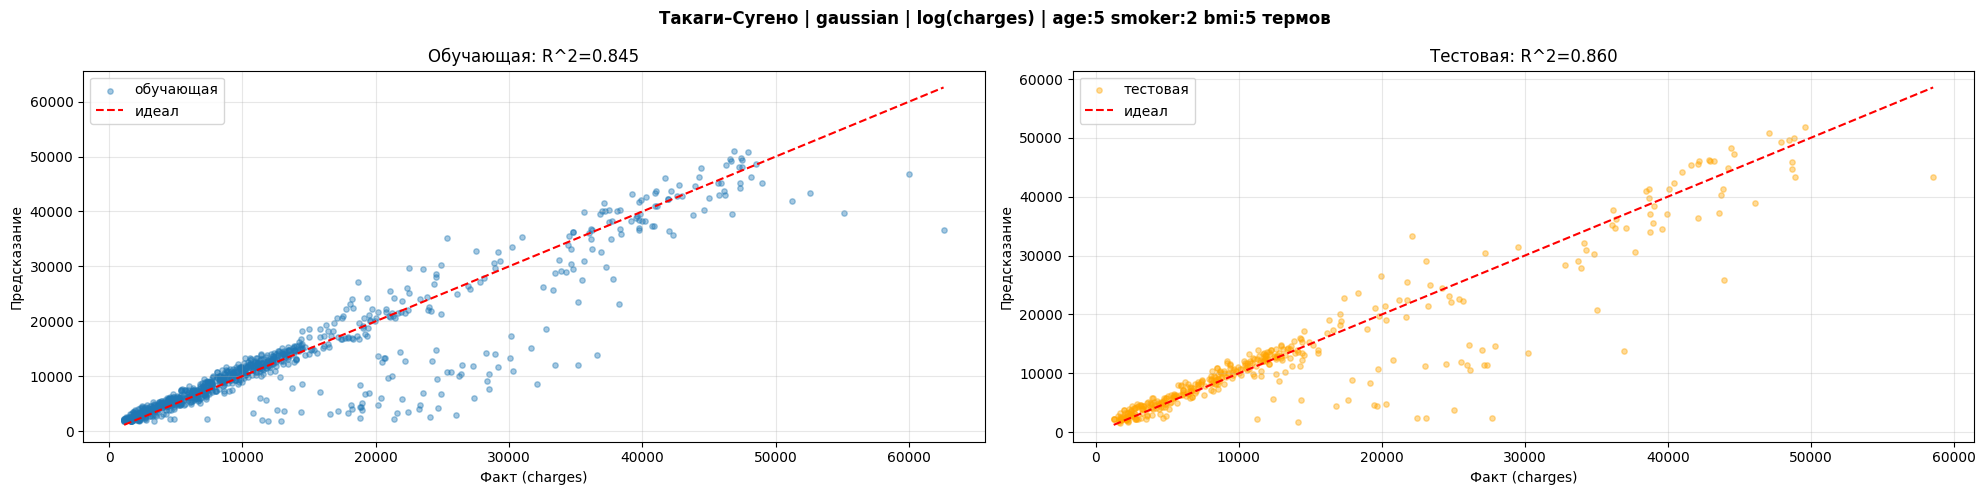

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].scatter(y_train, y_pred_train, alpha=0.4, s=15, label='обучающая')
lims = [min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='идеал')
axes[0].set_xlabel('Факт (charges)'); axes[0].set_ylabel('Предсказание')
axes[0].set_title(f'Обучающая: R^2={metrics_train["R2"]:.3f}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_test, alpha=0.4, s=15, color='orange', label='тестовая')
lims2 = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1].plot(lims2, lims2, 'r--', linewidth=1.5, label='идеал')
axes[1].set_xlabel('Факт (charges)'); axes[1].set_ylabel('Предсказание')
axes[1].set_title(f'Тестовая: R^2={metrics_test["R2"]:.3f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Такаги–Сугено | {MATH_FUNC_TYPE} | log(charges) | '
    f'age:{AGE_TERM_NUMBER} smoker:{SMOKER_TERM_NUMBER} bmi:{BMI_TERM_NUMBER} термов',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()